# Testing

In [1]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from dataset import SICAPMultiSlideDataset, get_slide_ids


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


In [2]:
FEATURES_DIR = "/home/nadun/wd/datasets/SICAP-test/features"
MASKS_DIR = "/home/nadun/wd/datasets/SICAP-test/masks"

## Create dataset

In [3]:
# Get all available slide IDs
slide_ids = get_slide_ids(FEATURES_DIR)
print(f"Total slides: {len(slide_ids)}")

dataset = SICAPMultiSlideDataset(
        slide_ids=slide_ids,
        features_dir=FEATURES_DIR,
        masks_dir=MASKS_DIR
    )
print(f"Total dataset size: {len(dataset)} patches")

Total slides: 155
Total dataset size: 18783 patches


### Visualize dataset

/home/nadun/wd/datasets/SICAP-test/masks/18B0005478J/18B0005478J_Block_Region_12_0_2_xini_38208_yini_48771.jpg
/home/nadun/wd/datasets/SICAP-test/masks/16B0024177/16B0024177_Block_Region_0_8_20_xini_42791_yini_116833.jpg
/home/nadun/wd/datasets/SICAP-test/masks/17B0027608/17B0027608_Block_Region_7_21_47_xini_63860_yini_66387.jpg
/home/nadun/wd/datasets/SICAP-test/masks/17B0028627/17B0028627_Block_Region_2_6_0_xini_5815_yini_109403.jpg
/home/nadun/wd/datasets/SICAP-test/masks/16B0024173/16B0024173_Block_Region_8_12_9_xini_15054_yini_13975.jpg


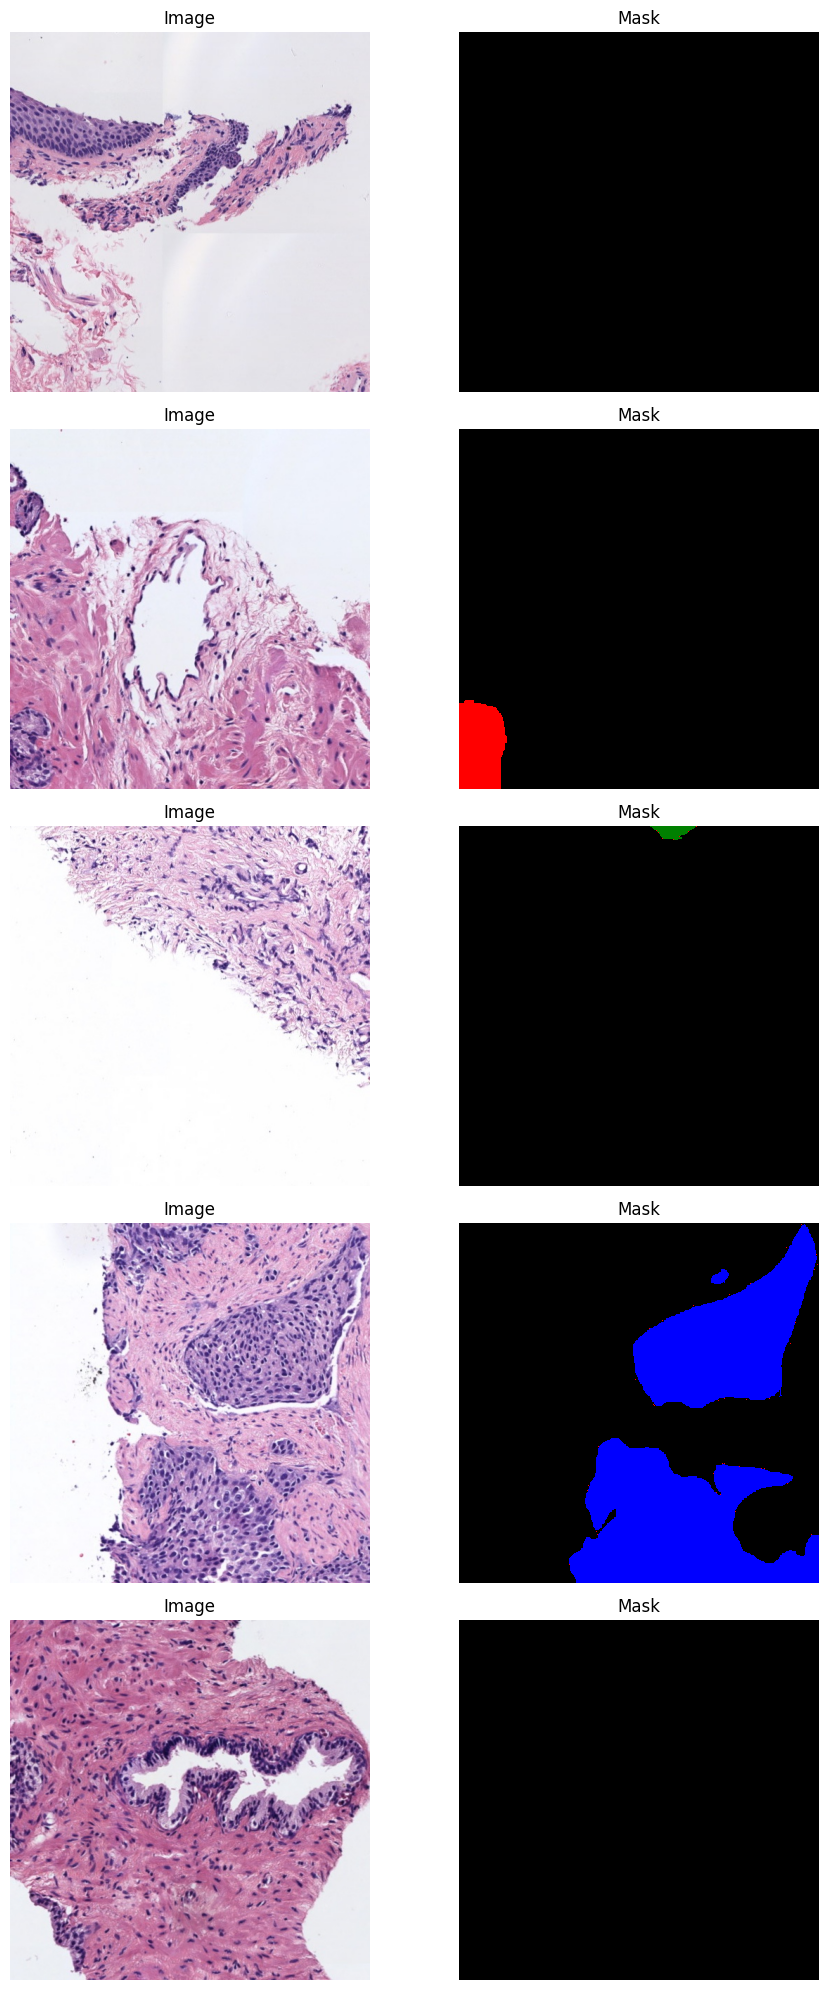

In [ ]:
# from matplotlib.colors import ListedColormap
# cmap = ListedColormap([
#     "black",   # class 0
#     "red",     # class 1
#     "green",   # class 2
#     "blue"     # class 3
# ])

# # Plot random samples and their masks
# num_samples = 5
# fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples))

# for i in range(num_samples):
#     idx = np.random.randint(0, len(dataset))
    
#     patch = dataset[idx]["filename"]
#     slide_id = dataset[idx]["slide_id"]
#     path = f"/home/nadun/wd/datasets/SICAP-test/images/{slide_id}/{patch}.jpg"
#     mask_path = f"/home/nadun/wd/datasets/SICAP-test/masks/{slide_id}/{patch}.jpg"
#     print(mask_path)

#     # Load image
#     image = Image.open(path).convert("RGB")
#     image = np.array(image)

#     # Load mask
#     mask = dataset[idx]["mask"].squeeze().cpu().numpy()  # [512, 512]

#     # Plot image
#     axes[i, 0].imshow(image)
#     axes[i, 0].set_title("Image")
#     axes[i, 0].axis("off")

#     # Plot mask (FIXED)
#     axes[i, 1].imshow(
#         mask,
#         cmap=cmap,
#         vmin=0,
#         vmax=3,
#         interpolation="nearest"
#     )
#     axes[i, 1].set_title("Mask")
#     axes[i, 1].axis("off")

# plt.tight_layout()
# plt.show()


## 

## Load CONCH backbone

In [5]:
from tqdm import tqdm
from conch.open_clip_custom import create_model_from_pretrained

/home/nadun/hdd/miniconda3/envs/conch/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
model_cfg = 'conch_ViT-B-16'
checkpoint_path = '/home/nadun/hdd/CONCH/checkpoints/conch/pytorch_model.bin'

model, preprocess = create_model_from_pretrained(model_cfg, checkpoint_path)
model.to(device).eval();

## Test CONCH backbone

In [10]:
image = Image.open("/home/nadun/wd/datasets/SICAP-test/images/17B0028627/17B0028627_Block_Region_2_25_6_xini_11959_yini_128859.jpg").convert('RGB')
image_tensor = preprocess(image).unsqueeze(0).to(device)

In [11]:
pooled_embedding, raw_tokens = model.visual(image_tensor)

In [12]:
raw_tokens.shape

torch.Size([1, 256, 768])

In [13]:
pooled_embedding.shape

torch.Size([1, 512])

## Load CONCH tokens

In [1]:
import torch
import numpy as np

In [2]:
# Import sample token
tokens = torch.load("/home/nadun/wd/datasets/SICAP-test/tokens/17B0028627/17B0028627_Block_Region_2_25_6_xini_11959_yini_128859.pt")

In [3]:
tokens.shape

torch.Size([768, 16, 16])